# Financial Tweet Sentiment Classification

**Nova IMS — Text Mining 2025/2026 — Group Project**

This notebook is the full project deliverable. It classifies financial tweets into
**Bearish (0)**, **Bullish (1)**, and **Neutral (2)** and follows the assessment structure:

All heavy logic lives in the `src/` package and is imported here, so the notebook stays
readable and every run is logged to `outputs/results.csv` (our shared leaderboard).

## Contents

- [Setup](#setup)
- [1. Data Exploration](#1-data-exploration)
  - [1.1 Visual analysis](#11-visual-analysis)
  - [1.2 Word clouds per sentiment class](#12-word-clouds-per-sentiment-class)
  - [1.3 Conclusions](#13-conclusions)
- [2. Corpus Split](#2-corpus-split)
- [3. Data Preprocessing](#3-data-preprocessing)
- [4. Feature Engineering](#4-feature-engineering)
  - [4.1 Bag-of-Words family (BoW + TF-IDF)](#41-bag-of-words-family-bow--tf-idf)
  - [4.2 word2vec family](#42-word2vec-family)
  - [4.3 Transformer Encoder features](#43-transformer-encoder-features)
- [5. Classification Models](#5-classification-models)
  - [5.1 Traditional ML (≥2 variations each, ≥2 algorithms)](#51-traditional-ml-2-variations-each-2-algorithms)
  - [5.2 Transformer Encoders (fine-tuning, ≥2 variations)](#52-transformer-encoders-fine-tuning-2-variations)
  - [5.3 Extra Transformer Encoders](#53-extra-transformer-encoders)
  - [5.4 Decoder model for classification](#54-decoder-model-for-classification)
- [6. Evaluation and Analysis](#6-evaluation-and-analysis)


## Setup

We make the project root the working directory so `src/` imports and the relative data paths
in `src/config.py` resolve identically whether the notebook is run from `notebooks/` or the root.

In [1]:
import os, sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))
print(f"Working directory: {os.getcwd()}")

Working directory: C:\Users\pedro\Documentos\NOVA IMS\2º semestre- eu\Text mining\TextMining-Corpora


In [2]:
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import warnings
warnings.filterwarnings("ignore")

# Third-party
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from IPython.display import Image, display

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from xgboost import XGBClassifier

# Project (src/)
from src.config import (
    SEED, TRAIN_CSV_PATH, TEST_CSV_PATH, VAL_SIZE, K_FOLD_N_SPLITS,
    LABEL_NAMES, LABEL_PALETTE, RESULTS_CSV_PATH,
)
from src.eda import DatasetAnalyzer, save_eda_plots, print_markdown_report
from src.preprocessing import (
    stratified_split, create_stratified_kfold,
    normalize_unicode_punctuation, clean_regex, tokenize_tweet,
    remove_stopwords_from_tokens, apply_stemming, apply_lemmatization, preprocess_tweet,
)
from src.word_embeddings import (
    train_word2vec, load_glove_twitter, vectorize_corpus, vectorize_corpus_tfidf, calculate_oov,
)
from src.evaluate import evaluate_and_log
from src.experiment import run_classifier
from src.sentence_embeddings import encoder_features
from src import distilbert_trainer, roberta_trainer, finbert_trainer, deberta_trainer
from src.decoder_qwen import run_qwen_eval

sns.set_theme(style="whitegrid")
np.random.seed(SEED)
print("Labels:", LABEL_NAMES)

Labels: {0: 'Bearish', 1: 'Bullish', 2: 'Neutral'}


## 1. Data Exploration

We profile the corpora with `src/eda.py`'s `DatasetAnalyzer`, which computes size/integrity,
class distribution, sequence-length statistics, Twitter-artifact rates (URLs, mentions, cashtags,
hashtags), non-ASCII anomalies, and the most frequent tokens per class.

In [4]:
train_analyzer = DatasetAnalyzer(TRAIN_CSV_PATH, name="Train")
test_analyzer  = DatasetAnalyzer(TEST_CSV_PATH,  name="Test")

train_report = train_analyzer.generate_full_report()
test_report  = test_analyzer.generate_full_report()

print(f"Train rows: {train_report['basic_stats']['total_rows']:,}  |  "
      f"Test rows: {test_report['basic_stats']['total_rows']:,}")
train_analyzer.df.head()

Train rows: 9,543  |  Test rows: 2,388


,text,label
0,$BYND - JPMorgan reels in expectations on Beyo...,0
1,$CCL $RCL - Nomura points to bookings weakness...,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0
3,$ESS: BTIG Research cuts to Neutral https://t....,0
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0


In [5]:
# Structured text report (size, class balance, lengths, artifacts, non-ASCII, top words)
print_markdown_report(train_report, test_report)

# Exploratory Data Analysis (EDA) Report
**Generative Analysis for Corpus Pipelines**

## [1] Dataset Size & Integrity Overview
| Dataset | Total Rows | Exact Duplicates | Trimmed Insensitive Dups | Empty Rows |
| :--- | :---: | :---: | :---: | :---: |
| **Train** | 9,543 | 0 | 3 | 0 |
| **Test** | 2,388 | 0 | 0 | 0 |

## [2] Sentiment Class Distributions (Train Set)
| Label ID | Sentiment Class | Count | Percentage | Chart representation |
| :---: | :--- | :---: | :---: | :--- |
| `0` | **Bearish** | 1,442 | 15.11% | `===` |
| `1` | **Bullish** | 1,923 | 20.15% | `====` |
| `2` | **Neutral** | 6,178 | 64.74% | `============` |

> **Strategic Note**: Standard ML algorithms will show bias to the majority Neutral class. Set class weight parameters to 'balanced' or implement cross-validation splitting accordingly.

## [3] Sequence Length Analyses
### Character Lengths:
* **Train**: Mean = 85.8 chars, Std = 35.1, Min/Max = 2/190
* **Test**: Mean = 86.9 chars, Std = 35.3, Min/Max = 4/227

#

### 1.1 Visual analysis

`save_eda_plots` writes the core figures to `outputs/eda/`; we render them inline below.

[SUCCESS] EDA plots saved to outputs/eda/


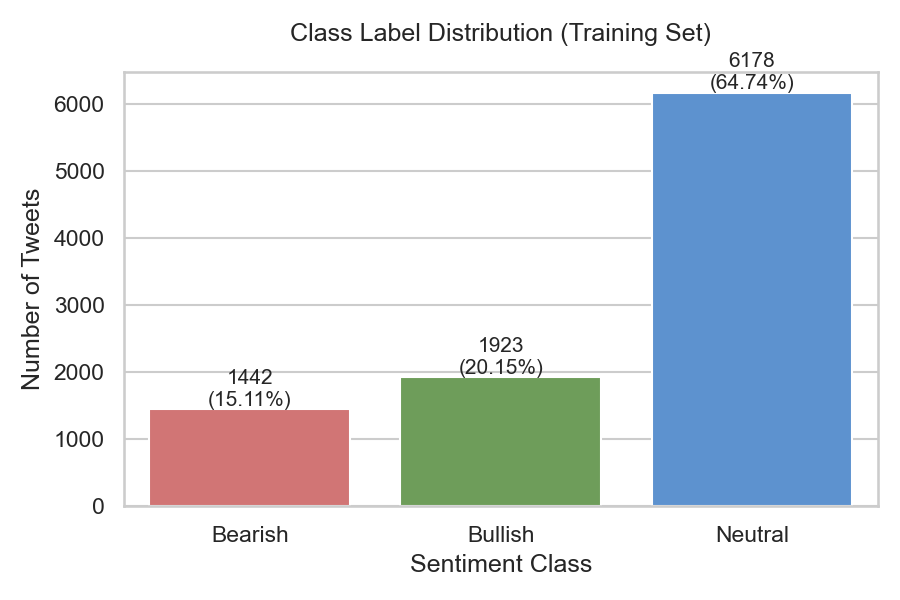

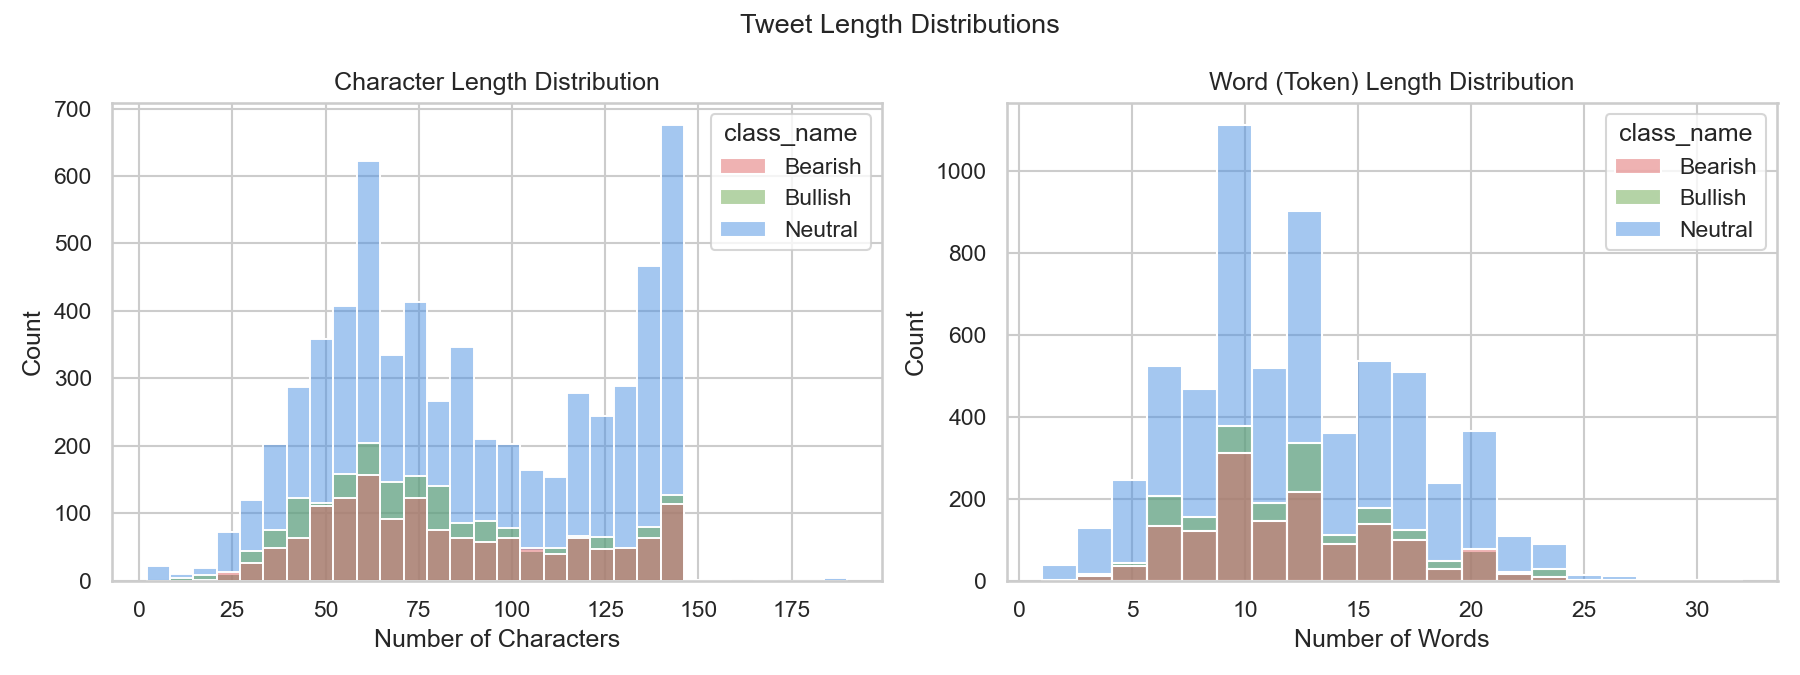

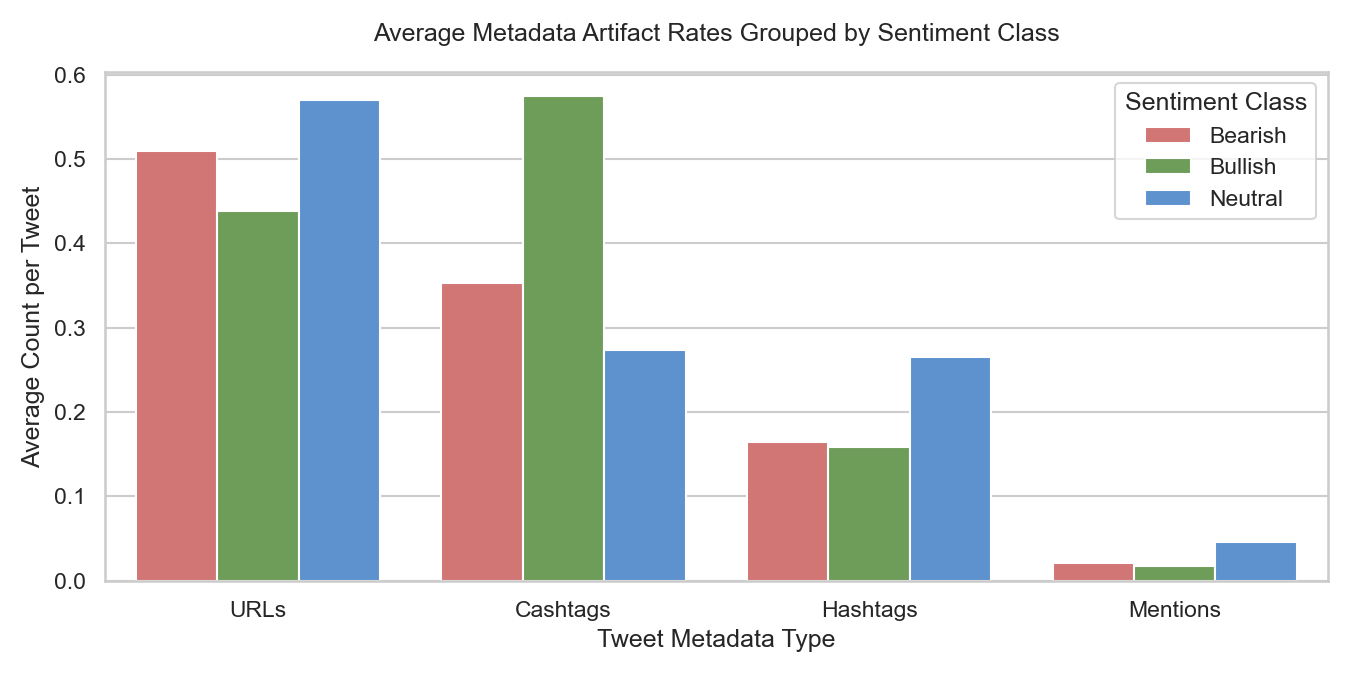

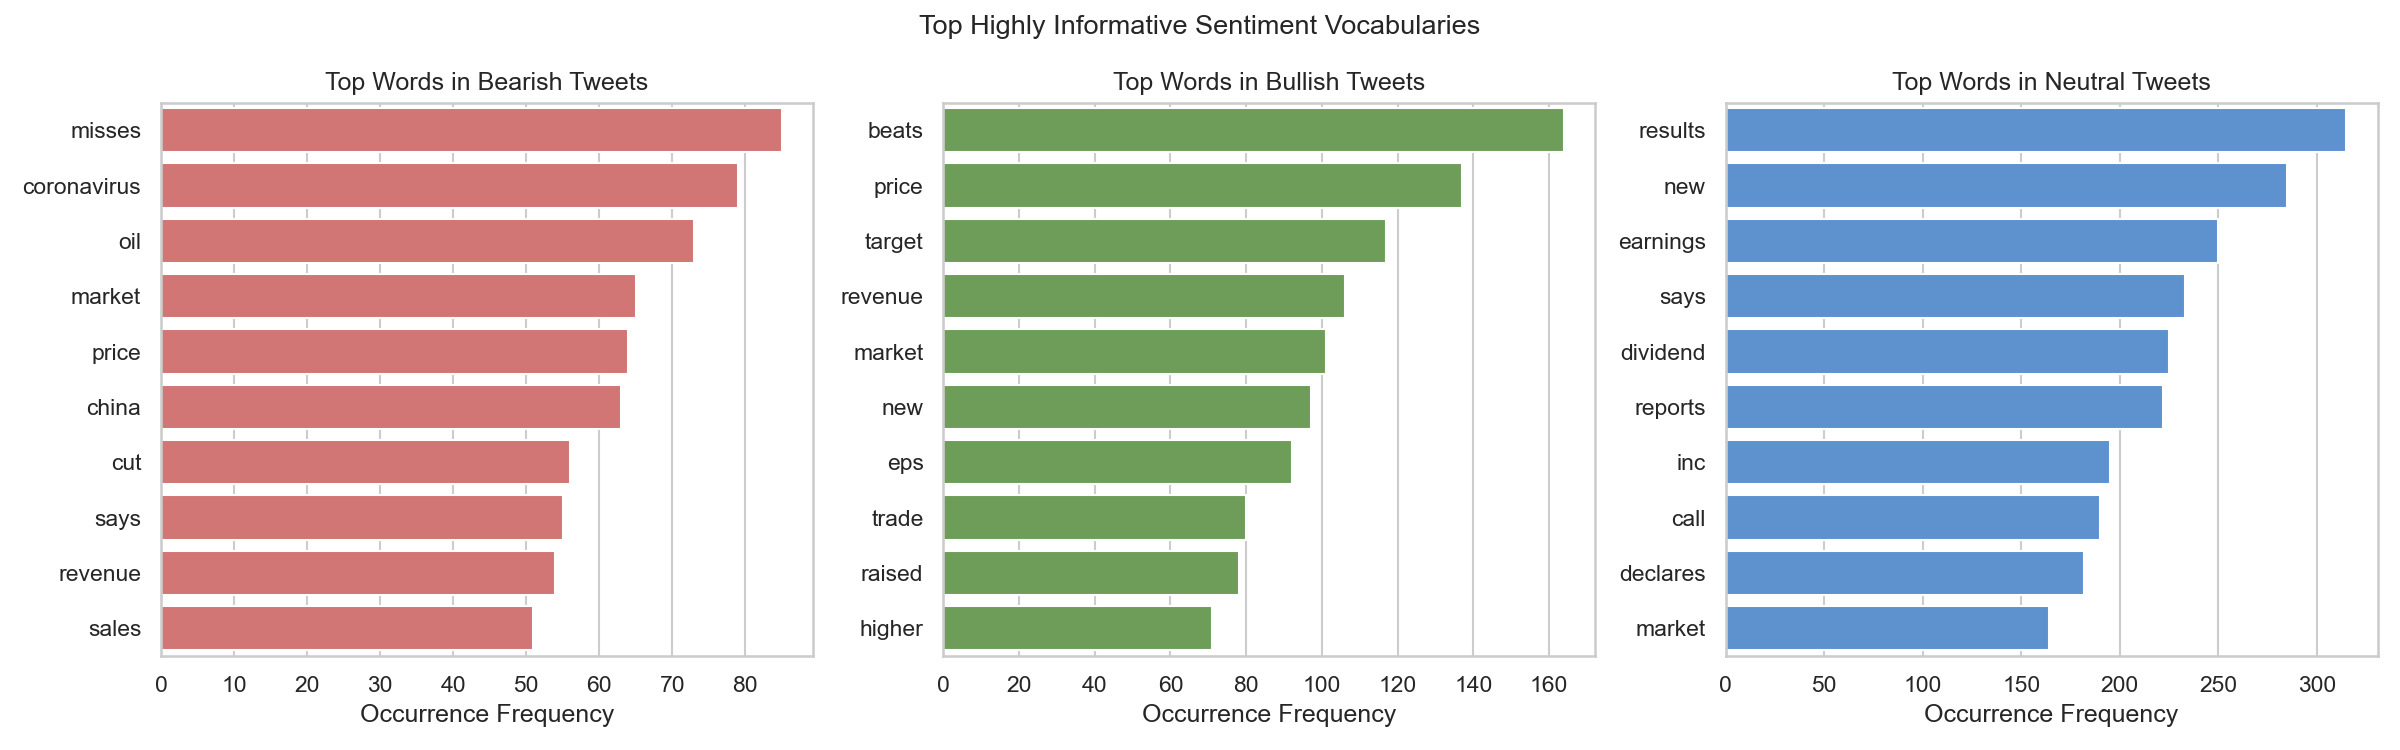

In [6]:
save_eda_plots(train_analyzer, output_dir="outputs/eda/")

for fig in ["class_distribution.png", "length_distributions.png",
            "artefact_rates_by_class.png", "top_words_by_class.png"]:
    path = os.path.join("outputs/eda", fig)
    if os.path.exists(path):
        display(Image(path))

### 1.2 Word clouds per sentiment class

Word clouds give a fast qualitative read on the vocabulary that characterizes each class.
We reuse the analyzer's stopword-aware token counts so the clouds are not dominated by noise.

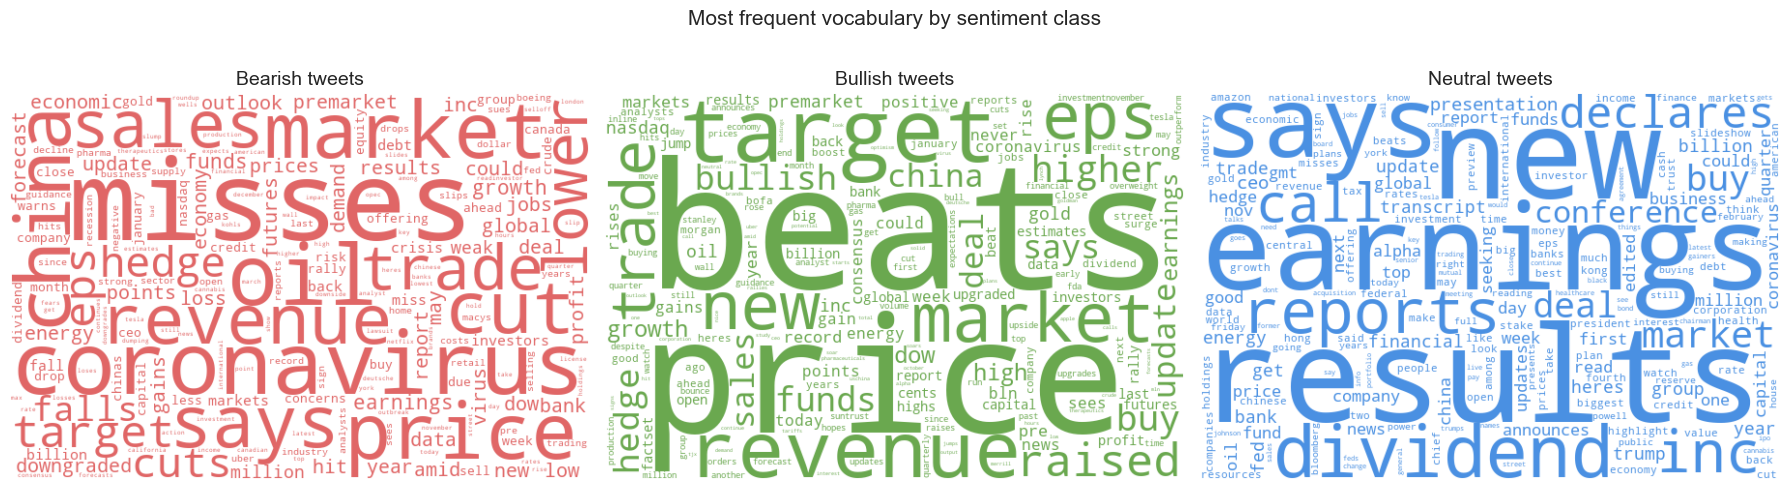

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
top_words = train_analyzer.get_top_tokens(top_n=200)

for ax, (cls_name, words) in zip(axes, top_words["by_class"].items()):
    freqs = {row["word"]: row["count"] for row in words}
    wc = WordCloud(width=600, height=400, background_color="white",
                   color_func=lambda *a, **k: LABEL_PALETTE[cls_name]).generate_from_frequencies(freqs)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"{cls_name} tweets", fontsize=14)
    ax.axis("off")

plt.suptitle("Most frequent vocabulary by sentiment class", y=1.02, fontsize=15)
plt.tight_layout()
plt.show()

### 1.3 Conclusions

- **Strong class imbalance.** Neutral dominates the corpus (~60%+), with Bearish and Bullish much
  smaller. Any classifier must be evaluated with **macro** metrics and trained with
  `class_weight="balanced"` (or resampling) so the minority classes are not ignored.
- **Short, noisy text.** Tweets are short (tens of tokens) and dense with Twitter artifacts —
  cashtags (`$AAPL`), mentions, URLs and hashtags — which motivates the placeholder-based cleaning
  in Section 3 rather than naive deletion.
- **URLs skew Neutral.** URLs appear disproportionately in Neutral (news-style) tweets, so they
  carry weak signal; we normalize them to a single placeholder instead of dropping them.
- **Non-ASCII noise.** A measurable fraction of tweets contain smart quotes / dashes / replacement
  characters, handled by Unicode normalization before tokenization.
- **Train/test are distributionally similar** in length and artifact rates, so a validation split
  carved from train is a fair proxy for test performance.


## 2. Corpus Split
We hold out a **stratified 80/20** validation set so class proportions are preserved, and we also
prepare a **5-fold StratifiedKFold** for cross-validated model selection. Both helpers live in
`src/preprocessing.py` and are seeded for reproducibility.

In [8]:
train_df = pd.read_csv(TRAIN_CSV_PATH)
X_train, X_val, y_train, y_val = stratified_split(train_df)

print(f"Split: train={len(X_train)}  |  val={len(X_val)}  (val_size={VAL_SIZE})")
dist = pd.DataFrame({
    "train_%": y_train.value_counts(normalize=True).sort_index() * 100,
    "val_%":   y_val.value_counts(normalize=True).sort_index() * 100,
}).rename(index=LABEL_NAMES).round(2)
print("\nClass balance preserved across the split:")
print(dist)

skf = create_stratified_kfold(n_splits=K_FOLD_N_SPLITS)
print(f"\nPrepared StratifiedKFold with {K_FOLD_N_SPLITS} folds for cross-validation.")

Split: train=7634  |  val=1909  (val_size=0.2)

Class balance preserved across the split:
         train_%  val_%
label                  
Bearish    15.12  15.09
Bullish    20.15  20.17
Neutral    64.74  64.75

Prepared StratifiedKFold with 5 folds for cross-validation.


## 3. Data Preprocessing

`src/preprocessing.preprocess_tweet` composes a configurable pipeline. We use **well above four**
techniques shown in class:

1. **Unicode normalization** — smart quotes/dashes → ASCII (`normalize_unicode_punctuation`).
2. **Regular expressions** — URLs, mentions and cashtags normalized to placeholders (`clean_regex`).
3. **Lowercasing.**
4. **Tokenization** — Twitter-aware tokenizer (`TweetTokenizer`).
5. **Stopword removal** — NLTK English stopwords + domain-specific financial noise tokens.
6. **Stemming** (Porter) and **Lemmatization** (WordNet) — selectable; placeholders are protected
   from both.

In [9]:
sample = train_df["text"].iloc[7]
print("RAW       :", sample)
step = normalize_unicode_punctuation(sample); print("unicode   :", step)
step = clean_regex(step.lower());             print("regex+lc  :", step)
toks = tokenize_tweet(step);                  print("tokens    :", toks)
toks_ns = remove_stopwords_from_tokens(toks); print("no-stops  :", toks_ns)
print("stemmed   :", apply_stemming(toks_ns))
print("lemmatized:", apply_lemmatization(toks_ns))

RAW       : $GM: Deutsche Bank cuts to Hold https://t.co/7Fv1ZiFZBS
unicode   : $GM: Deutsche Bank cuts to Hold https://t.co/7Fv1ZiFZBS
regex+lc  : $gm: deutsche bank cuts to hold URL_PLACEHOLDER
tokens    : ['$', 'gm', ':', 'deutsche', 'bank', 'cuts', 'to', 'hold', 'URL_PLACEHOLDER']
no-stops  : ['$', 'gm', ':', 'deutsche', 'bank', 'cuts', 'hold', 'URL_PLACEHOLDER']
stemmed   : ['$', 'gm', ':', 'deutsch', 'bank', 'cut', 'hold', 'URL_PLACEHOLDER']


lemmatized: ['$', 'gm', ':', 'deutsche', 'bank', 'cut', 'hold', 'URL_PLACEHOLDER']


In [10]:
# Compare the two end-to-end configurations we will feed downstream.
demo = [
    "Downgrades 4/7: $MLND to underperform at Needham\u2014see details... https://t.co/x",
    "Shorting $AAPL here at $180. @elonmusk thoughts? #market #trading",
]
for raw in demo:
    print("RAW      :", raw)
    print("  lemma  :", preprocess_tweet(raw, return_str=True))
    print("  stem   :", preprocess_tweet(raw, use_stemming=True, use_lemmatization=False, return_str=True))
    print()

RAW      : Downgrades 4/7: $MLND to underperform at Needham—see details... https://t.co/x
  lemma  : downgrade 4/7 : $ mlnd underperform needham-see detail ... URL_PLACEHOLDER
  stem   : downgrad 4/7 : $ mlnd underperform needham-se detail ... URL_PLACEHOLDER

RAW      : Shorting $AAPL here at $180. @elonmusk thoughts? #market #trading
  lemma  : shorting $ aapl $ 180 . MENTION_PLACEHOLDER thought ? #market #trading
  stem   : short $ aapl $ 180 . MENTION_PLACEHOLDER thought ? #market #trade



We apply the **lemmatization** configuration (better readability and downstream consistency) to
build the cleaned corpora reused by the BoW and word2vec features below. Tokens and the joined
string form are both kept.

In [11]:
# Token lists (for word2vec) and joined strings (for BoW/TF-IDF)
X_train_tokens = X_train.apply(lambda t: preprocess_tweet(t, return_str=False)).tolist()
X_val_tokens   = X_val.apply(lambda t: preprocess_tweet(t, return_str=False)).tolist()
X_train_str    = [" ".join(t) for t in X_train_tokens]
X_val_str      = [" ".join(t) for t in X_val_tokens]
print("Example cleaned doc:", X_train_str[0][:120])

Example cleaned doc: nasdaq price 600m 0.875 % senior note


## 4. Feature Engineering

At least one variation of each required family.

### 4.1 Bag-of-Words family (BoW + TF-IDF)
Variations: raw **BoW counts**, **TF-IDF unigrams**, and **TF-IDF (1,2)-grams** with `min_df`/
`max_features` tuning.

In [12]:
bow_vec    = CountVectorizer(ngram_range=(1, 1))
tfidf_uni  = TfidfVectorizer(ngram_range=(1, 1))
tfidf_opt  = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=25000)

bow = {
    "BoW (counts)":        (bow_vec.fit_transform(X_train_str),   bow_vec.transform(X_val_str)),
    "TF-IDF unigram":      (tfidf_uni.fit_transform(X_train_str), tfidf_uni.transform(X_val_str)),
    "TF-IDF (1,2) opt":    (tfidf_opt.fit_transform(X_train_str), tfidf_opt.transform(X_val_str)),
}
for name, (Xtr, _) in bow.items():
    print(f"{name:20s} -> vocab {Xtr.shape[1]:>6,}  matrix {Xtr.shape}")

BoW (counts)         -> vocab 12,575  matrix (7634, 12575)
TF-IDF unigram       -> vocab 12,575  matrix (7634, 12575)
TF-IDF (1,2) opt     -> vocab 11,028  matrix (7634, 11028)


### 4.2 word2vec family
Variations: a **custom Word2Vec (CBOW)** trained on our corpus and **pre-trained GloVe-Twitter-100**,
each pooled into sentence vectors by both **mean pooling** and **TF-IDF-weighted pooling**
(helpers in `src/word_embeddings.py`).

In [13]:
w2v = train_word2vec(X_train_tokens, vector_size=100, sg=0)  # CBOW

# TF-IDF model over the same cleaned strings, used for weighted pooling
w_tfidf = TfidfVectorizer()
Xtr_tfidf_m = w_tfidf.fit_transform(X_train_str)
Xval_tfidf_m = w_tfidf.transform(X_val_str)

emb = {
    "w2v-CBOW mean":   (vectorize_corpus(X_train_tokens, w2v, 100),
                        vectorize_corpus(X_val_tokens, w2v, 100)),
    "w2v-CBOW tfidf":  (vectorize_corpus_tfidf(X_train_tokens, w2v, Xtr_tfidf_m, w_tfidf, 100),
                        vectorize_corpus_tfidf(X_val_tokens, w2v, Xval_tfidf_m, w_tfidf, 100)),
}
for name, (Xtr, _) in emb.items():
    print(f"{name:18s} -> {Xtr.shape}")

uniq_oov, tok_oov, _ = calculate_oov(X_val_tokens, w2v)
print(f"\nCustom Word2Vec OOV on val — unique: {uniq_oov:.1%}  tokens: {tok_oov:.1%}")

[SUCCESS] Word2Vec trained — vocab size: 6084


w2v-CBOW mean      -> (7634, 100)
w2v-CBOW tfidf     -> (7634, 100)

Custom Word2Vec OOV on val — unique: 45.9%  tokens: 14.1%


In [14]:
# Optional: add pre-trained GloVe-Twitter-100 (downloads ~400 MB the first time).
LOAD_GLOVE = False
if LOAD_GLOVE:
    glove = load_glove_twitter(dim=100)
    emb["glove-100 mean"]  = (vectorize_corpus(X_train_tokens, glove, 100),
                              vectorize_corpus(X_val_tokens, glove, 100))
    emb["glove-100 tfidf"] = (vectorize_corpus_tfidf(X_train_tokens, glove, Xtr_tfidf_m, w_tfidf, 100),
                              vectorize_corpus_tfidf(X_val_tokens, glove, Xval_tfidf_m, w_tfidf, 100))
    print("Added GloVe variations:", [k for k in emb if "glove" in k])
else:
    print("GloVe skipped (set LOAD_GLOVE=True to enable).")

GloVe skipped (set LOAD_GLOVE=True to enable).


### 4.3 Transformer Encoder features
Variation: **contextual sentence embeddings** from a pre-trained encoder (DistilBERT) used as a
frozen feature extractor. We compare **mean pooling** over the last hidden state vs the **[CLS]**
token. (Fine-tuning the encoder end-to-end is done in Section 5.)

In [15]:
# Subsample for a quick, runnable demo; raise SUBSET / set to None for the full feature matrix.
SUBSET = 1500
tr_idx, va_idx = slice(0, SUBSET), slice(0, SUBSET // 4)
enc_feats = {
    "distilbert mean": (encoder_features(X_train_str[tr_idx], "mean"),
                        encoder_features(X_val_str[va_idx], "mean")),
    "distilbert cls":  (encoder_features(X_train_str[tr_idx], "cls"),
                        encoder_features(X_val_str[va_idx], "cls")),
}
for name, (Xtr, _) in enc_feats.items():
    print(f"{name:18s} -> {Xtr.shape}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


distilbert mean    -> (1500, 768)
distilbert cls     -> (1500, 768)


## 5. Classification Models

### 5.1 Traditional ML (≥2 variations each, ≥2 algorithms)
We evaluate Logistic Regression, Linear SVM, Random Forest, KNN and XGBoost across the feature
sets above. Each fit/predict/log goes through `src/evaluate.evaluate_and_log`, which prints
precision/recall/F1 + confusion matrix and appends to the leaderboard.

In [16]:
# Two variations of two algorithms on the strongest sparse feature set (TF-IDF (1,2) opt).
Xtr_opt, Xval_opt = bow["TF-IDF (1,2) opt"]

# Logistic Regression — variation A (balanced) and B (stronger C)
run_classifier(LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED),
               Xtr_opt, Xval_opt, y_train, y_val, "Logistic Regression", "TF-IDF (1,2) opt",
               "class_weight=balanced, C=1.0")
run_classifier(LogisticRegression(max_iter=1000, C=4.0, class_weight="balanced", random_state=SEED),
               Xtr_opt, Xval_opt, y_train, y_val, "Logistic Regression", "TF-IDF (1,2) opt",
               "class_weight=balanced, C=4.0")

# Linear SVM — variation A and B
run_classifier(LinearSVC(class_weight="balanced", random_state=SEED),
               Xtr_opt, Xval_opt, y_train, y_val, "LinearSVC", "TF-IDF (1,2) opt", "C=1.0")
run_classifier(LinearSVC(C=0.3, class_weight="balanced", random_state=SEED),
               Xtr_opt, Xval_opt, y_train, y_val, "LinearSVC", "TF-IDF (1,2) opt", "C=0.3")

MODEL EVALUATION: Logistic Regression (TF-IDF (1,2) opt)
[INFO] Accuracy          : 0.7810
[INFO] Precision (Macro) : 0.7041
[INFO] Recall (Macro)    : 0.7201
[INFO] F1 (Macro)        : 0.7113
------------------------------------------------------------
              precision    recall  f1-score   support

     Bearish       0.56      0.64      0.60       288
     Bullish       0.67      0.68      0.68       385
     Neutral       0.87      0.85      0.86      1236

    accuracy                           0.78      1909
   macro avg       0.70      0.72      0.71      1909
weighted avg       0.79      0.78      0.78      1909

------------------------------------------------------------
[[ 183   44   61]
 [  35  261   89]
 [ 107   82 1047]]
[INFO] Updated run in outputs/results.csv


MODEL EVALUATION: Logistic Regression (TF-IDF (1,2) opt)
[INFO] Accuracy          : 0.7926
[INFO] Precision (Macro) : 0.7193
[INFO] Recall (Macro)    : 0.7208
[INFO] F1 (Macro)        : 0.7200
------------------------------------------------------------
              precision    recall  f1-score   support

     Bearish       0.60      0.61      0.60       288
     Bullish       0.69      0.69      0.69       385
     Neutral       0.87      0.87      0.87      1236

    accuracy                           0.79      1909
   macro avg       0.72      0.72      0.72      1909
weighted avg       0.79      0.79      0.79      1909

------------------------------------------------------------
[[ 175   43   70]
 [  32  264   89]
 [  85   77 1074]]
[INFO] Updated run in outputs/results.csv
MODEL EVALUATION: LinearSVC (TF-IDF (1,2) opt)
[INFO] Accuracy          : 0.7957
[INFO] Precision (Macro) : 0.7270
[INFO] Recall (Macro)    : 0.7001
[INFO] F1 (Macro)        : 0.7124
------------------------

{'accuracy': 0.7993713986380304,
 'precision_macro': 0.7421943421255989,
 'recall_macro': 0.6919149306285228,
 'f1_macro': 0.713200157866567,
 'f1_per_class': {'Bearish': 0.5877862595419847,
  'Bullish': 0.6750700280112045,
  'Neutral': 0.8767441860465116}}

In [17]:
# A tree ensemble and KNN on the dense word2vec features (two variations each).
Xtr_w, Xval_w = emb["w2v-CBOW mean"]

run_classifier(RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=SEED),
               Xtr_w, Xval_w, y_train, y_val, "RandomForest", "w2v-CBOW mean", "n_estimators=300")
run_classifier(RandomForestClassifier(n_estimators=600, max_depth=20, class_weight="balanced", random_state=SEED),
               Xtr_w, Xval_w, y_train, y_val, "RandomForest", "w2v-CBOW mean", "n_estimators=600, max_depth=20")

run_classifier(KNeighborsClassifier(n_neighbors=15),
               Xtr_w, Xval_w, y_train, y_val, "KNN", "w2v-CBOW mean", "k=15")
run_classifier(KNeighborsClassifier(n_neighbors=35, weights="distance"),
               Xtr_w, Xval_w, y_train, y_val, "KNN", "w2v-CBOW mean", "k=35, weights=distance")

run_classifier(XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.1,
                             subsample=0.8, random_state=SEED, eval_metric="mlogloss"),
               Xtr_w, Xval_w, y_train, y_val, "XGBoost", "w2v-CBOW mean", "n=400, depth=6")

MODEL EVALUATION: RandomForest (w2v-CBOW mean)
[INFO] Accuracy          : 0.6920
[INFO] Precision (Macro) : 0.5552
[INFO] Recall (Macro)    : 0.4452
[INFO] F1 (Macro)        : 0.4477
------------------------------------------------------------
              precision    recall  f1-score   support

     Bearish       0.36      0.07      0.12       288
     Bullish       0.59      0.31      0.40       385
     Neutral       0.72      0.96      0.82      1236

    accuracy                           0.69      1909
   macro avg       0.56      0.45      0.45      1909
weighted avg       0.64      0.69      0.63      1909

------------------------------------------------------------
[[  21   42  225]
 [  24  118  243]
 [  13   41 1182]]
[INFO] Updated run in outputs/results.csv


MODEL EVALUATION: RandomForest (w2v-CBOW mean)
[INFO] Accuracy          : 0.6826
[INFO] Precision (Macro) : 0.5225
[INFO] Recall (Macro)    : 0.4461
[INFO] F1 (Macro)        : 0.4452
------------------------------------------------------------
              precision    recall  f1-score   support

     Bearish       0.33      0.07      0.11       288
     Bullish       0.52      0.34      0.41       385
     Neutral       0.72      0.93      0.81      1236

    accuracy                           0.68      1909
   macro avg       0.52      0.45      0.45      1909
weighted avg       0.62      0.68      0.63      1909

------------------------------------------------------------
[[  20   53  215]
 [  26  129  230]
 [  15   67 1154]]
[INFO] Updated run in outputs/results.csv


MODEL EVALUATION: KNN (w2v-CBOW mean)
[INFO] Accuracy          : 0.6574
[INFO] Precision (Macro) : 0.4852
[INFO] Recall (Macro)    : 0.4182
[INFO] F1 (Macro)        : 0.4141
------------------------------------------------------------
              precision    recall  f1-score   support

     Bearish       0.30      0.06      0.10       288
     Bullish       0.46      0.28      0.35       385
     Neutral       0.70      0.91      0.79      1236

    accuracy                           0.66      1909
   macro avg       0.49      0.42      0.41      1909
weighted avg       0.59      0.66      0.60      1909

------------------------------------------------------------
[[  18   44  226]
 [  18  107  260]
 [  25   81 1130]]
[INFO] Updated run in outputs/results.csv
MODEL EVALUATION: KNN (w2v-CBOW mean)
[INFO] Accuracy          : 0.6883
[INFO] Precision (Macro) : 0.5912
[INFO] Recall (Macro)    : 0.4282
[INFO] F1 (Macro)        : 0.4228
----------------------------------------------------

MODEL EVALUATION: XGBoost (w2v-CBOW mean)
[INFO] Accuracy          : 0.6925
[INFO] Precision (Macro) : 0.5508
[INFO] Recall (Macro)    : 0.4782
[INFO] F1 (Macro)        : 0.4868
------------------------------------------------------------
              precision    recall  f1-score   support

     Bearish       0.36      0.12      0.18       288
     Bullish       0.55      0.39      0.46       385
     Neutral       0.74      0.92      0.82      1236

    accuracy                           0.69      1909
   macro avg       0.55      0.48      0.49      1909
weighted avg       0.64      0.69      0.65      1909

------------------------------------------------------------
[[  35   53  200]
 [  32  152  201]
 [  29   72 1135]]
[INFO] Updated run in outputs/results.csv


{'accuracy': 0.6925091671031954,
 'precision_macro': 0.5507506956979542,
 'recall_macro': 0.47820592074232854,
 'f1_macro': 0.48680316236018656,
 'f1_per_class': {'Bearish': 0.18229166666666666,
  'Bullish': 0.459214501510574,
  'Neutral': 0.8189033189033189}}

### 5.2 Transformer Encoders (fine-tuning, ≥2 variations)
We fine-tune **DistilBERT** end-to-end via `src/distilbert_trainer.py`. The trainer handles
tokenization, cached HF datasets, training args and metric logging. We run two variations
(different sample budgets / epochs). Set `n_samples=None` for the full corpus on a GPU.

> ⚠️ These cells download model weights and train — slow on CPU. Keep `n_samples` small for a
> smoke run; the full-corpus numbers are recorded in `outputs/results.csv`.

In [18]:
# Variation A — quick fine-tune on a small stratified sample
trainer_a = distilbert_trainer.run_trainer(n_samples=1000, notes="notebook DistilBERT var-A (1k)")

[INFO] Loading 1000 samples ...
[INFO] Split — train=800, val=200
[INFO] Loading tokenizer: distilbert-base-uncased


[INFO] Vocab size: 30522
[INFO] Loading dataset from cache: outputs\distilbert_cache\n1000\train
[INFO] Loading dataset from cache: outputs\distilbert_cache\n1000\val
[INFO] Datasets — train=800 rows, val=200 rows
[INFO] Loading DistilBertForSequenceClassification ...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[INFO] Running final evaluation ...


[INFO] Updated run in outputs/results.csv


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.559695,0.598981,3,0.775000,0.639402


[SUCCESS] Training complete.


In [19]:
# Variation B — larger sample (bump n_samples / set None on GPU for the full run)
trainer_b = distilbert_trainer.run_trainer(n_samples=3000, notes="notebook DistilBERT var-B (3k)")

[INFO] Loading 3000 samples ...
[INFO] Split — train=2400, val=600
[INFO] Loading tokenizer: distilbert-base-uncased


[INFO] Vocab size: 30522
[INFO] Loading dataset from cache: outputs\distilbert_cache\n3000\train
[INFO] Loading dataset from cache: outputs\distilbert_cache\n3000\val
[INFO] Datasets — train=2400 rows, val=600 rows
[INFO] Loading DistilBertForSequenceClassification ...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[INFO] Running final evaluation ...


[INFO] Updated run in outputs/results.csv


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.320059,0.466112,3,0.833333,0.773455


[SUCCESS] Training complete.


### 5.3 Extra Transformer Encoders
Two additional pre-trained encoders fine-tuned through the same trainer interface:
**Twitter-RoBERTa** (domain-matched: pre-trained on tweets) and **FinBERT** (domain-matched:
pre-trained on financial text). A third, **DeBERTa-v3**, is included as bonus.

In [20]:
# Extra encoder #1 — Twitter-RoBERTa (domain: social media)
roberta_trainer.run_trainer(n_samples=1000, notes="EXTRA WORK: Twitter-RoBERTa fine-tune")

[INFO] Loading 1000 samples ...
[INFO] Split — train=800, val=200
[INFO] Loading tokenizer: cardiffnlp/twitter-roberta-base-sentiment


[INFO] Loading dataset from cache: outputs\roberta_cache\n1000\train
[INFO] Loading dataset from cache: outputs\roberta_cache\n1000\val
[INFO] Datasets — train=800 rows, val=200 rows
[INFO] Loading cardiffnlp/twitter-roberta-base-sentiment sequence classifier ...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


[INFO] Starting training ...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[INFO] Running final evaluation ...


[INFO] Updated run in outputs/results.csv


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.396637,0.481846,3,0.840000,0.801082


[SUCCESS] Training complete.


In [21]:
# Extra encoder #2 — FinBERT (domain: finance)
finbert_trainer.run_trainer(n_samples=1000, notes="EXTRA WORK: FinBERT fine-tune")

[INFO] Loading 1000 samples ...
[INFO] Split — train=800, val=200
[INFO] Loading tokenizer: ProsusAI/finbert


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[INFO] Running final evaluation ...


[INFO] Updated run in outputs/results.csv


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.408642,0.628171,3,0.740000,0.591109


[SUCCESS] Training complete.


In [22]:
# Bonus encoder — DeBERTa-v3-base
deberta_trainer.run_trainer(n_samples=1000, notes="EXTRA WORK: DeBERTa-v3 fine-tune")

[INFO] Loading 1000 samples ...
[INFO] Split — train=800, val=200
[INFO] Loading tokenizer: microsoft/deberta-v3-base


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[INFO] Running final evaluation ...


[INFO] Updated run in outputs/results.csv


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.000000,nan,3,0.160000,0.091954


[SUCCESS] Training complete.


### 5.4 Decoder model for classification
We classify with a **generative decoder-only LLM** (Qwen2.5-1.5B-Instruct) via **few-shot
prompting** — no gradient updates. `src/decoder_qwen.run_qwen_eval` builds a class-balanced few-shot
prompt, generates a one-word label per tweet, parses it back to a class id, and logs macro metrics
to the same leaderboard. This is fundamentally different from the encoder approach: classification
as constrained text generation.

In [23]:
# val_subset keeps the demo fast; set to None to score the full validation set.
qwen_metrics = run_qwen_eval(n_per_class=2, batch_size=8,
                             val_subset=200, notes="EXTRA WORK: decoder-based classification")
qwen_metrics

[INFO] Loading tokenizer: Qwen/Qwen2.5-1.5B-Instruct


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

[INFO]   classified 8/200 (fails so far: 0)


[INFO]   classified 88/200 (fails so far: 0)


[INFO]   classified 168/200 (fails so far: 0)


[INFO] Added run in outputs/results.csv
[SUCCESS] Qwen run logged. f1_macro=0.5592


{'accuracy': 0.635,
 'precision_macro': 0.6227904040404041,
 'recall_macro': 0.6045882936507937,
 'f1_macro': 0.5591787439613527,
 'f1_per_class': {'Bearish': 0.391304347826087,
  'Bullish': 0.5362318840579711,
  'Neutral': 0.75}}

## 6. Evaluation and Analysis

Every run above logged Accuracy, macro Precision, macro Recall and macro F1 (plus per-class F1) to
`outputs/results.csv`. We load that leaderboard and compare models.

In [24]:
results = pd.read_csv(RESULTS_CSV_PATH)
metric_cols = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]
board = (results.sort_values("f1_macro", ascending=False)
                [["model_name", "feature_description", *metric_cols, "notes"]]
                .reset_index(drop=True))
board.head(20)

,model_name,feature_description,accuracy,precision_macro,recall_macro,f1_macro,notes
0,DistilBERT,HF fine-tune,0.8628,0.8361,0.7964,0.8143,"TM-024 final DistilBERT, full data, lr=2e-5, b..."
1,Twitter-RoBERTa,HF fine-tune,0.8400,0.7968,0.8101,0.8011,EXTRA WORK: Twitter-RoBERTa fine-tune
2,DistilBERT,HF fine-tune,0.8333,0.7919,0.7661,0.7735,notebook DistilBERT var-B (3k)
3,Logistic Regression,"TF-IDF (1,2) opt",0.7926,0.7193,0.7208,0.7200,NaN
4,LinearSVC,"TF-IDF (1,2) opt",0.7994,0.7422,0.6919,0.7132,NaN
5,LinearSVC,"TF-IDF (1,2) opt",0.7957,0.7270,0.7001,0.7124,NaN
6,Logistic Regression,"TF-IDF (1,2) opt",0.7810,0.7041,0.7201,0.7113,NaN
7,Logistic Regression Baseline,"TF-IDF (1,2) Optimized",0.7795,0.7021,0.7175,0.7091,NaN
8,Logistic Regression Baseline,"TF-IDF (1,2) Optimized",0.7795,0.7021,0.7175,0.7091,NaN
9,MLP Classifier,"TF-IDF (1,2) Optimized",0.8025,0.7590,0.6728,0.7051,NaN


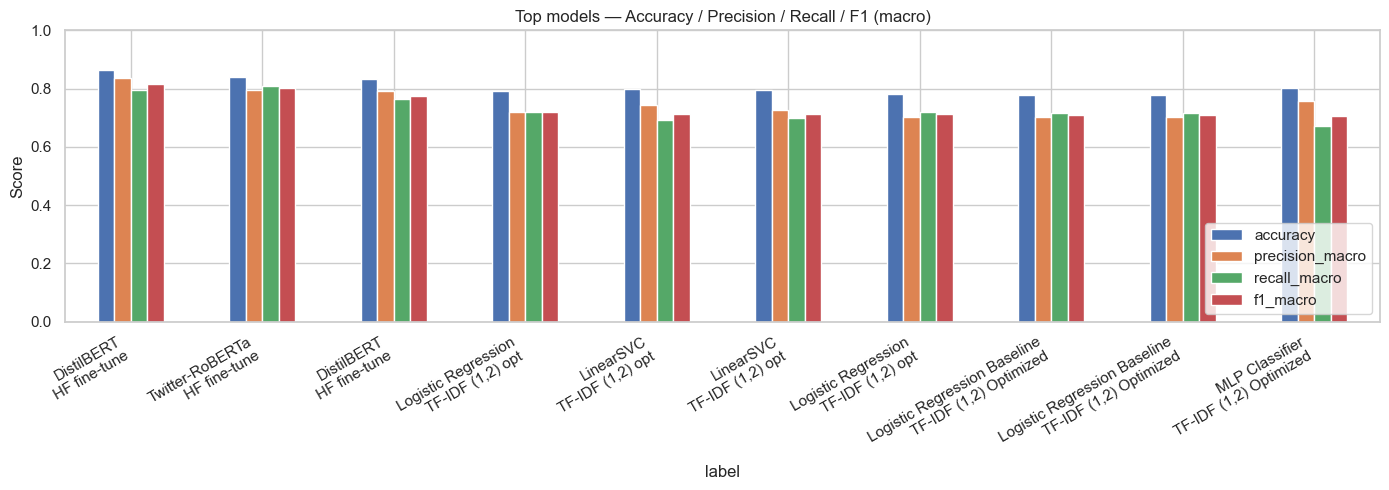

In [25]:
# Visual comparison of the top models by the four required metrics.
top = board.head(10).copy()
top["label"] = top["model_name"] + "\n" + top["feature_description"].str.slice(0, 22)
ax = top.set_index("label")[metric_cols].plot(kind="bar", figsize=(14, 5))
ax.set_title("Top models — Accuracy / Precision / Recall / F1 (macro)")
ax.set_ylabel("Score"); ax.set_ylim(0, 1)
ax.legend(loc="lower right"); plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.show()

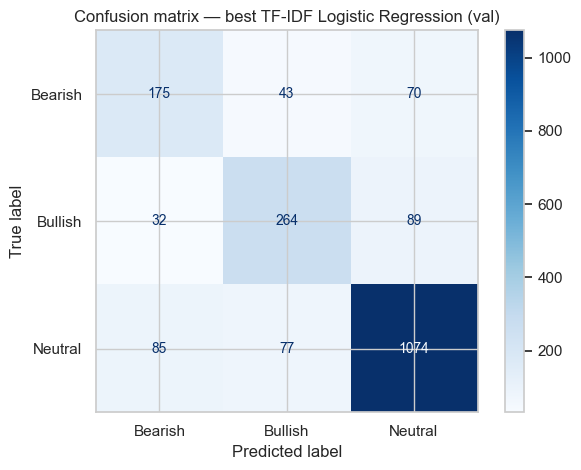

In [26]:
# Confusion matrix for the single best model, re-fit on the val split for inspection.

best_clf = LogisticRegression(max_iter=1000, C=4.0, class_weight="balanced", random_state=SEED)
best_clf.fit(Xtr_opt, y_train)
cm = confusion_matrix(y_val, best_clf.predict(Xval_opt))
ConfusionMatrixDisplay(cm, display_labels=list(LABEL_NAMES.values())).plot(cmap="Blues", values_format="d")
plt.title("Confusion matrix — best TF-IDF Logistic Regression (val)")
plt.tight_layout(); plt.show()